# S6E2 Logistic Regression Tuning

Systematic search over regularization strength (`C`) and penalty type (`l1` vs `l2`).

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import subprocess, re
from io import StringIO

KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    if "heart_disease" in df.columns:
        df["heart_disease"] = df["heart_disease"].map({"Absence": 0, "Presence": 1})
    for col in ["chest_pain_type","ekg_results","slope_of_st","number_of_vessels_fluro","thallium"]:
        if col in df.columns: df[col] = df[col].astype(int)
    return df

train = prep(pd.read_csv(DATA_DIR / "train.csv"))
test  = prep(pd.read_csv(DATA_DIR / "test.csv"))
ss    = pd.read_csv(DATA_DIR / "sample_submission.csv")

FEATURES = [c for c in train.columns if c not in ["heart_disease", "id"]]
X = train[FEATURES]; y = train["heart_disease"]; X_test = test[FEATURES]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Features: {FEATURES}")

Features: ['age', 'sex', 'chest_pain_type', 'bp', 'cholesterol', 'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina', 'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']


## L1 vs L2 Regularization — What They Do

Both are ways to prevent overfitting by penalizing large coefficients, but they behave differently:

**L2 (Ridge)** — default in sklearn LR
- Shrinks all coefficients toward zero but never to exactly zero
- All features stay in the model, just with reduced influence
- Good when you believe every feature contributes *something*
- Handles correlated features gracefully by splitting weight between them

**L1 (Lasso)**
- Can drive coefficients to *exactly* zero = built-in feature selection
- Tends to pick one feature from a correlated group and zero out the rest
- Good when you suspect many features are irrelevant or redundant
- For this dataset: `bp` (r=−0.005) and `fbs_over_120` (r=0.034) are candidates to be zeroed out

**ElasticNet** — mix of both, rarely needed unless you have thousands of features

**For this dataset:** L2 is likely better since most features have at least some signal and
the correlated features (thallium, chest_pain, exercise_angina) all carry independent information.
L1 is still worth testing — if it zeros out `bp`/`fbs_over_120` and scores higher, that's useful signal.

**`C` parameter:** inverse of regularization strength. Low C = strong regularization, high C = weak.
Default C=1. On large datasets like this (630k rows), overfitting is less of a concern,
so higher C values often work better.

## Grid Search: C × Penalty

In [2]:
param_grid = {
    "logisticregression__C":       [0.01, 0.1, 1, 10, 100],
    "logisticregression__penalty": ["l1", "l2"],
}

# saga solver supports both l1 and l2
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="saga", max_iter=2000, random_state=42)
)

grid = GridSearchCV(
    pipe, param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y)
print(f"\nBest params : {grid.best_params_}")
print(f"Best ROC-AUC: {grid.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits



Best params : {'logisticregression__C': 0.01, 'logisticregression__penalty': 'l1'}
Best ROC-AUC: 0.9505


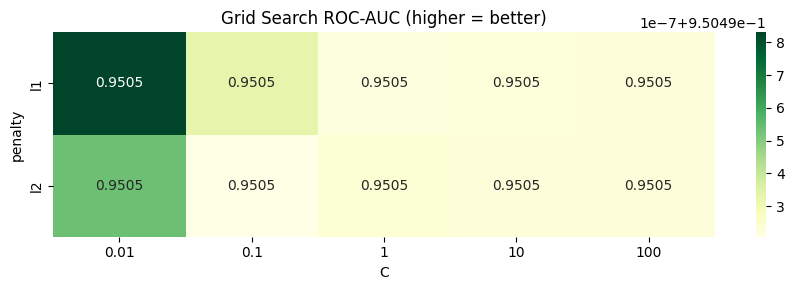


Top 5 combinations:
penalty     C  mean_test_score  std_test_score
     l1  0.01         0.950491        0.000338
     l2  0.01         0.950491        0.000337
     l1   0.1         0.950490        0.000337
     l2     1         0.950490        0.000337
     l1   100         0.950490        0.000337


In [3]:
# Full results heatmap
results = pd.DataFrame(grid.cv_results_)
results["C"]       = results["param_logisticregression__C"]
results["penalty"] = results["param_logisticregression__penalty"]

pivot_auc = results.pivot(index="penalty", columns="C", values="mean_test_score")
pivot_acc = results.pivot(index="penalty", columns="C",
    values="mean_test_score")  # reuse for layout; accuracy plotted separately

import seaborn as sns
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot_auc, annot=True, fmt=".4f", cmap="YlGn", ax=ax)
ax.set_title("Grid Search ROC-AUC (higher = better)")
plt.tight_layout()
plt.show()

print("\nTop 5 combinations:")
print(results[["penalty","C","mean_test_score","std_test_score"]]
      .sort_values("mean_test_score", ascending=False)
      .head()
      .to_string(index=False))

## Coefficient Inspection — Does L1 Zero Anything Out?

In [4]:
# Fit best model and also fit L1 equivalent to compare coefficients
best_C = grid.best_params_["logisticregression__C"]
best_pen = grid.best_params_["logisticregression__penalty"]

for penalty in ["l1", "l2"]:
    lr = make_pipeline(StandardScaler(),
                       LogisticRegression(C=best_C, penalty=penalty,
                                          solver="saga", max_iter=2000, random_state=42))
    lr.fit(X, y)
    coefs = pd.Series(lr.named_steps["logisticregression"].coef_[0], index=FEATURES)
    zeroed = coefs[coefs == 0].index.tolist()
    print(f"penalty={penalty}  C={best_C}  zeroed out: {zeroed if zeroed else 'none'}")
    print(coefs.sort_values(key=abs, ascending=False).round(4).to_string())
    print()

penalty=l1  C=0.01  zeroed out: none
thallium                   0.9618
chest_pain_type            0.8852
max_hr                    -0.8344
number_of_vessels_fluro    0.7021
exercise_angina            0.5398
sex                        0.4816
st_depression              0.4599
slope_of_st                0.4419
age                        0.3498
ekg_results                0.2171
cholesterol                0.0949
fbs_over_120              -0.0089
bp                         0.0022



penalty=l2  C=0.01  zeroed out: none
thallium                   0.9619
chest_pain_type            0.8856
max_hr                    -0.8350
number_of_vessels_fluro    0.7030
exercise_angina            0.5408
sex                        0.4828
st_depression              0.4609
slope_of_st                0.4428
age                        0.3512
ekg_results                0.2185
cholesterol                0.0966
fbs_over_120              -0.0109
bp                         0.0041



## Submit Best Model

In [5]:
best_lr = grid.best_estimator_
best_lr.fit(X, y)

cv_auc = grid.best_score_
cv_acc = cross_val_score(best_lr, X, y, cv=cv, scoring="accuracy").mean()

preds = best_lr.predict(X_test)
sub = ss.copy()
sub["Heart Disease"] = preds

best_C   = grid.best_params_["logisticregression__C"]
best_pen = grid.best_params_["logisticregression__penalty"]
model_name = f"lr_{best_pen}_C{best_C}"
fname = f"submissions/{model_name}.csv"
desc  = f"{model_name} | cv_acc={cv_acc:.4f} | cv_auc={cv_auc:.4f}"

sub.to_csv(fname, index=False)
print(f"Saved : {fname}")
print(f"Desc  : {desc}")

Saved : submissions/lr_l1_C0.01.csv
Desc  : lr_l1_C0.01 | cv_acc=0.8831 | cv_auc=0.9505


In [6]:
import subprocess
result = subprocess.run(
    ["kaggle", "competitions", "submit", "-c", "playground-series-s6e2",
     "-f", fname, "-m", desc],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

Successfully submitted to Predicting Heart Disease

  0%|          | 0.00/2.32M [00:00<?, ?B/s]
  1%|          | 16.0k/2.32M [00:00<00:28, 84.1kB/s]
 15%|█▍        | 352k/2.32M [00:00<00:01, 1.43MB/s] 
100%|██████████| 2.32M/2.32M [00:01<00:00, 2.13MB/s]

